## 1. Configuration & Setup

In [1]:
import os
print(os.getcwd())

/content


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/MLPS'
os.makedirs(PROJECT_PATH, exist_ok=True)
os.chdir(PROJECT_PATH)
print(f"Current working directory: {os.getcwd()}")

Mounted at /content/drive
Current working directory: /content/drive/MyDrive/MLPS


In [3]:
# Check dependencies
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'xarray': 'xarray',
    'netCDF4': 'netCDF4',
    'matplotlib': 'matplotlib',
    'torch': 'torch',
    'statsmodels': 'statsmodels',
    'tqdm': 'tqdm'
}

missing_packages = []
for package_name, import_name in required_packages.items():
    try:
        __import__(import_name)
        print(f"✓ {package_name} is installed")
    except ImportError as e:
        print(f"✗ {package_name} is NOT installed - {str(e)}")
        missing_packages.append(package_name)

if missing_packages:
    print(f"\n⚠️  Missing packages: {', '.join(missing_packages)}")
else:
    print("\n✓ All required packages are installed!")

✓ numpy is installed
✓ pandas is installed
✓ xarray is installed
✗ netCDF4 is NOT installed - No module named 'netCDF4'
✓ matplotlib is installed
✓ torch is installed
✓ statsmodels is installed
✓ tqdm is installed

⚠️  Missing packages: netCDF4


In [4]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.6 MB/s eta 0:00:00


In [5]:
#%%
# ============== META VARIABLES ==============
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Data paths
DATA_DIR = "data/"
RESULTS_DIR = "results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.nc")

# The test_24h_demo.nc and test_48h_demo.nc are just demo files, so the outages in those files are just noise
# TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h.nc")
# TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h.nc")
TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h_demo.nc")
TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h_demo.nc")

# Model parameters
VALIDATION_SPLIT = 0.2  # Use last 20% of training data for validation

# SARIMAX parameters
SARIMAX_ORDER = (1, 0, 1)  # (p, d, q)

# Seq2Seq parameters
SEQ_LEN = 24       # Lookback window (hours) for the seq2seq model
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3
HIDDEN_DIM = 64
NUM_LAYERS = 1

# Set device for PyTorch
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Configuration loaded successfully!")
print(f"Random Seed: {RANDOM_SEED}")
print(f"Device: {DEVICE}")
print(f"Data Directory: {DATA_DIR}")
print(f"Results Directory: {RESULTS_DIR}")

Configuration loaded successfully!
Random Seed: 42
Device: cpu
Data Directory: data/
Results Directory: results/


## 2. Data Loading

Load the NetCDF datasets and explore their structure.

In [6]:
# Load datasets
ds_train = xr.open_dataset(TRAIN_PATH)
ds_test_24h = xr.open_dataset(TEST_24H_PATH)
ds_test_48h = xr.open_dataset(TEST_48H_PATH)

print(ds_train)

<xarray.Dataset> Size: 159MB
Dimensions:    (location: 83, timestamp: 2161, feature: 109)
Coordinates:
  * location   (location) <U5 2kB '26001' '26003' '26005' ... '26163' '26165'
  * timestamp  (timestamp) datetime64[ns] 17kB 2023-04-01 ... 2023-06-30
  * feature    (feature) object 872B 'SBT113' 'SBT114' 'SBT123' ... 'wz' 'wz_1'
    state      (location) <U2 664B ...
Data variables:
    tracked    (location, timestamp) float64 1MB ...
    out        (location, timestamp) float64 1MB ...
    weather    (location, timestamp, feature) float64 156MB ...
Attributes:
    time_start:  2022-01-01T00:00:00
    time_end:    2022-01-31T23:00:00
    time_now:    2025-07-08T14:59:10


In [7]:
# Extract basic information
train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = list(ds_train.location.values)
weather_features = list(ds_train.feature.values) if 'feature' in ds_train.dims else []

print(f"Training Period: {train_timestamps.min()} to {train_timestamps.max()}")
print(f"Number of Timestamps: {len(train_timestamps)}")
print(f"Number of Locations: {len(locations)}")
print(f"Locations: {locations}")
print(f"\nWeather Features ({len(weather_features)}): {weather_features}")

# Extract outage data
outage_data = ds_train.out.transpose("timestamp", "location").values.astype(float)
print(f"\nOutage Data Shape: {outage_data.shape} (timestamps x locations)")
print(f"Outage Statistics:")
print(f"  Mean: {np.nanmean(outage_data):.2f}")
print(f"  Std: {np.nanstd(outage_data):.2f}")
print(f"  Min: {np.nanmin(outage_data):.2f}")
print(f"  Max: {np.nanmax(outage_data):.2f}")

Training Period: 2023-04-01 00:00:00 to 2023-06-30 00:00:00
Number of Timestamps: 2161
Number of Locations: 83
Locations: [np.str_('26001'), np.str_('26003'), np.str_('26005'), np.str_('26007'), np.str_('26009'), np.str_('26011'), np.str_('26013'), np.str_('26015'), np.str_('26017'), np.str_('26019'), np.str_('26021'), np.str_('26023'), np.str_('26025'), np.str_('26027'), np.str_('26029'), np.str_('26031'), np.str_('26033'), np.str_('26035'), np.str_('26037'), np.str_('26039'), np.str_('26041'), np.str_('26043'), np.str_('26045'), np.str_('26047'), np.str_('26049'), np.str_('26051'), np.str_('26053'), np.str_('26055'), np.str_('26057'), np.str_('26059'), np.str_('26061'), np.str_('26063'), np.str_('26065'), np.str_('26067'), np.str_('26069'), np.str_('26071'), np.str_('26073'), np.str_('26075'), np.str_('26077'), np.str_('26079'), np.str_('26081'), np.str_('26083'), np.str_('26085'), np.str_('26087'), np.str_('26089'), np.str_('26091'), np.str_('26093'), np.str_('26095'), np.str_('2609

In [8]:
# Load test datasets
print("Loading test datasets...")

test_24h_timestamps = ds_test_24h.timestamp.values
test_48h_timestamps = ds_test_48h.timestamp.values

print(f"✓ Test 24h: {len(test_24h_timestamps)} timestamps")
print(f"✓ Test 48h: {len(test_48h_timestamps)} timestamps")

print(f"\nTesting Period (24h): {test_24h_timestamps.min()} to {test_24h_timestamps.max()}")
print(f"Testing Period (48h): {test_48h_timestamps.min()} to {test_48h_timestamps.max()}")

Loading test datasets...
✓ Test 24h: 24 timestamps
✓ Test 48h: 48 timestamps

Testing Period (24h): 2023-06-30T01:00:00.000000000 to 2023-07-01T00:00:00.000000000
Testing Period (48h): 2023-06-30T01:00:00.000000000 to 2023-07-02T00:00:00.000000000


## 3. Exploratory Data Analysis

In [9]:
# Data quality check
print("Shape (location, time, feature):", ds_train.weather.shape)

print("\nTime range:")
print("Min:", train_timestamps.min())
print("Max:", train_timestamps.max())

# Check time interval consistency
time_diff = np.diff(train_timestamps) / np.timedelta64(1, 'h')
print("\nUnique time intervals (hours):", np.unique(time_diff))

# Check missing value ratios
def check_nan_ratio(x, name):
    total = x.size
    nan_count = np.isnan(x).sum()
    print(f"{name} NaN ratio: {nan_count / total:.4f}")

check_nan_ratio(ds_train.weather.values, "weather")
check_nan_ratio(ds_train.out.values, "out")
check_nan_ratio(ds_train.tracked.values, "tracked")

# Check duplicate timestamps
print("\nCheck duplicates:")
print("Unique timestamps:", len(np.unique(train_timestamps)))
print("Total timestamps:", len(train_timestamps))


Shape (location, time, feature): (83, 2161, 109)

Time range:
Min: 2023-04-01 00:00:00
Max: 2023-06-30 00:00:00

Unique time intervals (hours): [1.]
weather NaN ratio: 0.0000
out NaN ratio: 0.0000
tracked NaN ratio: 0.0000

Check duplicates:
Unique timestamps: 2161
Total timestamps: 2161


In [15]:
# handling outliers
weather = ds_train.weather.copy()

# compute IQR
Q1 = weather.quantile(0.25, dim="timestamp")
Q3 = weather.quantile(0.75, dim="timestamp")
IQR = Q3 - Q1

# define lower and upper bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# replace outliers with NaN
weather_clean = weather.where((weather >= lower) & (weather <= upper))

# in the next step, all the NAN values will be filled!

In [16]:
# handling missing values
#It fills missing values by linearly interpolating--
# --along the time dimension using neighboring timestamps.

weather_filled = weather_clean.interpolate_na( dim="timestamp", method="linear" )


Basic statistics:
count    179363.000000
mean         45.248334
std         452.269701
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       23346.000000
dtype: float64
Zero ratio: 0.7047


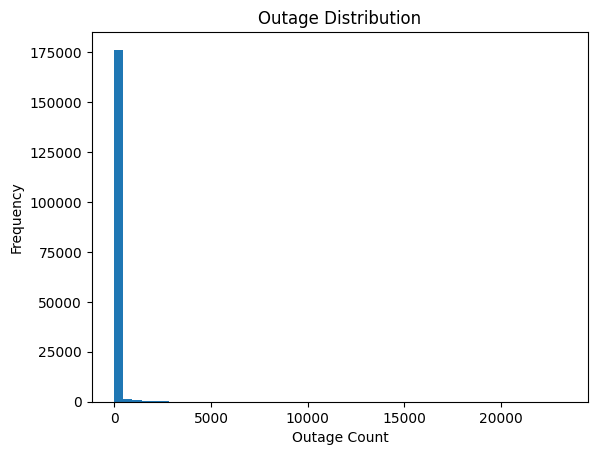

In [10]:
# outcome variable

out = ds_train.out.values.flatten()
print("Basic statistics:")
print(pd.Series(out).describe())

# Proportion of zero values (zero-inflatedg)
zero_ratio = np.mean(out == 0)
print(f"Zero ratio: {zero_ratio:.4f}")

# Plot distribution
plt.figure()
plt.hist(out, bins=50)
plt.title("Outage Distribution")
plt.xlabel("Outage Count")
plt.ylabel("Frequency")
plt.show()



               mean     max  count
location                          
26001     14.038871  4199.0   2161
26003     33.974086  3064.0   2161
26005     25.361407  3676.0   2161
26007      0.323924   154.0   2161
26009     14.307728  2462.0   2161
26011     19.776030  2094.0   2161
26013     15.410921  1263.0   2161
26015     15.121240  1782.0   2161
26017      7.657103  1838.0   2161
26019      7.485886  1837.0   2161


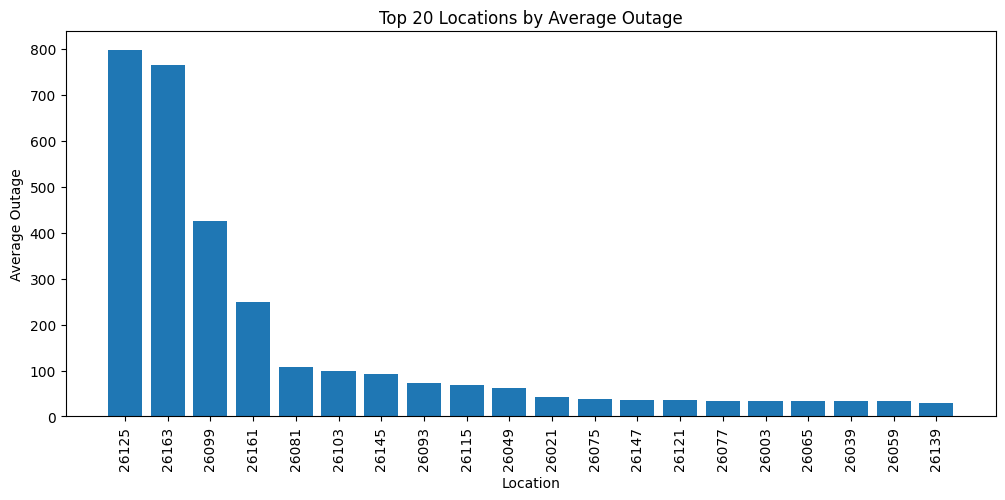

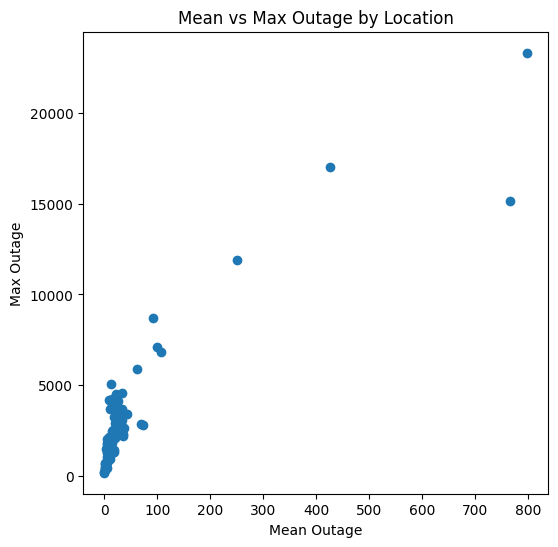

In [14]:
# LOCATION-LEVEL ANALYSIS


# create dataframes
df_out = pd.DataFrame({
    "location": np.repeat(locations, len(train_timestamps)),
    "out": ds_train.out.values.flatten()
})

# aggregate outcome values by location
location_stats = df_out.groupby("location")["out"].agg(["mean", "max", "count"])
print(location_stats.head(10))

location_stats_sorted = location_stats.sort_values("mean", ascending=False)

plt.figure(figsize=(12,5))
plt.bar(location_stats_sorted.index[:20], location_stats_sorted["mean"][:20])
plt.xticks(rotation=90)
plt.title("Top 20 Locations by Average Outage")
plt.xlabel("Location")
plt.ylabel("Average Outage")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(location_stats["mean"], location_stats["max"])

plt.xlabel("Mean Outage")
plt.ylabel("Max Outage")
plt.title("Mean vs Max Outage by Location")

plt.show()


In [17]:
# WEATHER FEATURE ANALYSIS

# Convert to numpy
weather_np = weather_filled.values

# standardize
mean = np.nanmean(weather_np, axis=1, keepdims=True)
std = np.nanstd(weather_np, axis=1, keepdims=True)

weather_std = (weather_np - mean) / (std + 1e-6)

# Compute feature volatility (standard deviation across location and time)
feature_volatility = np.nanstd(weather_std, axis=(0, 1))

# This code standardizes the weather features and identifies
#the most volatile ones by computing their standard deviation
#across all locations and timestamps.
top_idx = np.argsort(feature_volatility)[-10:]
top_features = [weather_features[i] for i in top_idx]

print("Top volatile weather features:")
print(top_features)

Top volatile weather features:
['sp', 'mslma', 'gh_5', 'gh_6', 'gh_7', 'pres_1', 'pres_2', 'plpl', 'vis', 'pcdb']


In [22]:

# CHECK CONSTANT / ALL-ZERO FEATURES & All-zero samples

weather_flat = weather_filled.values.reshape(-1, weather_filled.shape[-1])
print(weather_flat.shape)

#checks whether each feature consists entirely of zeros across all samples
all_zero_mask = np.all(weather_flat == 0, axis=0)
zero_features = [weather_features[i] for i in range(len(weather_features)) if all_zero_mask[i]]

print(f"Number of all-zero features: {len(zero_features)}")
print("All-zero features:")
print(zero_features)
# can delete these features before training models ?

all_zero_sample_mask = np.all(weather_flat == 0, axis=1)
num_all_zero_samples = np.sum(all_zero_sample_mask)

print(f"Number of all-zero samples: {num_all_zero_samples}")
print(f"Ratio: {num_all_zero_samples / len(weather_flat):.4f}")


(179363, 109)
Number of all-zero features: 19
All-zero features:
['aod', 'bgrun', 'cfnsf', 'cfrzr', 'cicep', 'crain', 'csnow', 'hail_1', 'hail_2', 'ltng', 'prate', 'sdwe_1', 'siconc', 'ssrun', 'tcoli', 'tcolw', 'tp', 'unknown_7', 'unknown_9']
Number of all-zero samples: 0
Ratio: 0.0000


Top correlated feature pairs:
t2m     pt        0.992003
pt      t2m       0.992003
t       sulwrf    0.984161
sulwrf  t         0.984161
SBT124  SBT114    0.979073
SBT114  SBT124    0.979073
r_1     r         0.976330
r       r_1       0.976330
gh_6    gh_7      0.976221
gh_7    gh_6      0.976221
dtype: float64


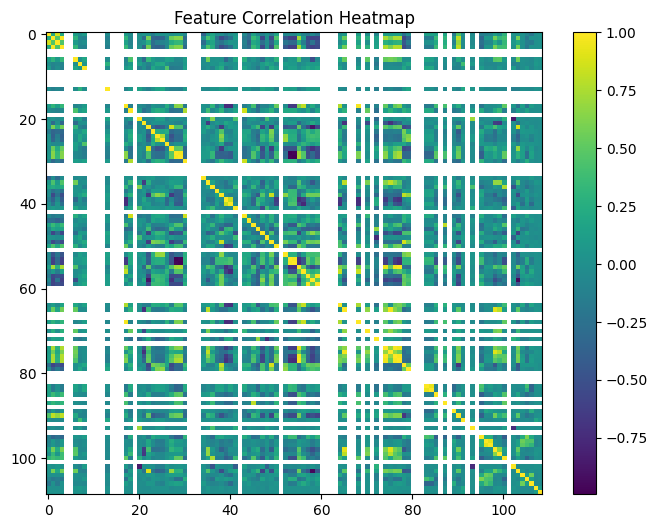

In [20]:

# feature correlation

df_weather = pd.DataFrame(weather_flat, columns=weather_features)

# Compute correlation matrix
corr_matrix = df_weather.corr()

# Show top correlated pairs
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)

# Remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 0.999]

print("Top correlated feature pairs:")
print(corr_pairs.head(10))

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.title("Feature Correlation Heatmap")
plt.show()

In [21]:
# FEATURE vs TARGET CORRELATION


out_flat = ds_train.out.values.flatten()
df_weather["out"] = out_flat

# Compute correlation with target
target_corr = df_weather.corr()["out"].drop("out")

# Sort
target_corr_sorted = target_corr.sort_values(ascending=False)

print("Top positively correlated features:")
print(target_corr_sorted.head(10))

print("\nTop negatively correlated features:")
print(target_corr_sorted.tail(10))

Top positively correlated features:
gh_4      0.141690
pwat      0.087514
sh2       0.083154
cape_1    0.078551
sdlwrf    0.071528
d2m       0.065559
lcc       0.054681
tcc       0.053949
pcdb      0.053770
r         0.049113
Name: out, dtype: float64

Top negatively correlated features:
snowc       NaN
ssrun       NaN
tcoli       NaN
tcolw       NaN
tp          NaN
unknown_1   NaN
unknown_3   NaN
unknown_7   NaN
unknown_9   NaN
veril       NaN
Name: out, dtype: float64


## 4. Data Preparation

In [23]:
ds_train_clean = xr.Dataset(
    {
        "weather": weather_filled,           # cleaned weather
        "tracked": ds_train.tracked,         # original
        "out": ds_train.out                  # original
    },
    coords={
        "location": ds_train.location,
        "timestamp": ds_train.timestamp,
        "feature": ds_train.feature
    }
)

print(ds_train_clean)

<xarray.Dataset> Size: 159MB
Dimensions:    (location: 83, feature: 109, timestamp: 2161)
Coordinates:
  * location   (location) <U5 2kB '26001' '26003' '26005' ... '26163' '26165'
  * feature    (feature) object 872B 'SBT113' 'SBT114' 'SBT123' ... 'wz' 'wz_1'
  * timestamp  (timestamp) datetime64[ns] 17kB 2023-04-01 ... 2023-06-30
    state      (location) <U2 664B ...
Data variables:
    weather    (location, timestamp, feature) float64 156MB nan 252.8 ... 0.0244
    tracked    (location, timestamp) float64 1MB 1.259e+04 ... 2.046e+04
    out        (location, timestamp) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0


In [25]:
# train-valid split based on timestamp
T = ds_train_clean.dims["timestamp"]

# Split index
split_idx = int((1 - VALIDATION_SPLIT) * T)

print(f"Total timestamps: {T}")
print(f"Split index: {split_idx}")

# Split timestamps
train_timestamps = ds_train_clean.timestamp[:split_idx]
val_timestamps = ds_train_clean.timestamp[split_idx:]

# Create train and validation datasets
train_data = ds_train_clean.sel(timestamp=train_timestamps)
val_data = ds_train_clean.sel(timestamp=val_timestamps)

print("\nTrain shape:", train_data.weather.shape)
print("Validation shape:", val_data.weather.shape)

Total timestamps: 2161
Split index: 1728

Train shape: (83, 1728, 109)
Validation shape: (83, 433, 109)


use "train_data" and "val_data" for advanced model training

In [ ]:
def evaluate_rmse_per_county(df, pred_col):
    """
    df: must contain ['timestamp', 'location', 'out', pred_col]
    pred_col: specify the name of predecited column （例如 'pred'）
    """

    rmses = []

    # sort
    df = df.sort_values(['location', 'timestamp'])

    for loc, group in df.groupby('location'):
        y_true = group['out'].values
        y_pred = group[pred_col].values

        if len(y_true) == len(y_pred):
            rmse_loc = np.sqrt(np.mean((y_true - y_pred) ** 2))
            rmses.append(rmse_loc)

    return np.mean(rmses)

In [ ]:
# the function below is used for data paration for baseline model only
def build_long_df(data, timestamps):
    rows = []
    T, N = data.shape

    for t in range(T):
        for loc_idx in range(N):
            rows.append([
                timestamps[t],   # timr
                loc_idx,         # location index
                data[t, loc_idx] # outage
            ])

    df = pd.DataFrame(rows, columns=['timestamp', 'location', 'out'])

    return df

full_df = build_long_df(outage_data, train_timestamps)

full_df = full_df.sort_values(['location', 'timestamp'])

full_df['timestamp'] = pd.to_datetime(full_df['timestamp'])

full_df['hour'] = full_df['timestamp'].dt.hour
full_df['dayofweek'] = full_df['timestamp'].dt.dayofweek

full_df['lag_1'] = full_df.groupby('location')['out'].shift(1)
full_df['lag_24'] = full_df.groupby('location')['out'].shift(24)

split_time = train_timestamps[split_idx]
train_df = full_df[full_df['timestamp'] <= split_time]
val_df   = full_df[full_df['timestamp'] > split_time]
print(train_df.shape)
print(val_df.shape)

(143507, 7)
(35856, 7)


## 5. Baseline Model

#### 5.1 Persistence

In [ ]:
def persistence_model(df):
    df = df.copy()

    df['pred'] = df.groupby('location')['out'].shift(1)

    df = df.dropna(subset=['pred'])

    return df

#### 5.2 Historical Mean / Median

In [ ]:
def historical_median_model(train_df, val_df):
    train_df = train_df.copy()
    val_df = val_df.copy()

    median_table = train_df.groupby(['location', 'hour'])['out'].median()

    val_df = val_df.merge(
        median_table.rename('pred'),
        on=['location', 'hour'],
        how='left'
    )

    return val_df

#### 5.3 Hurdle

In [ ]:
def train_hurdle(train_df):
    train_df = train_df.copy()
    features = ['lag_1', 'lag_24', 'hour', 'dayofweek']
    train_df = train_df.dropna(subset=features + ['out'])

    train_df = train_df[~np.isinf(train_df[features]).any(axis=1)]

    train_df['is_outage'] = (train_df['out'] > 0).astype(int)

    # Step 1: Logistic
    X_logit = sm.add_constant(train_df[features])
    y_logit = train_df['is_outage']

    logit_model = sm.Logit(y_logit, X_logit).fit(disp=False)

    # Step 2: Poisson
    train_nonzero = train_df[train_df['out'] > 0]

    X_pois = sm.add_constant(train_nonzero[features])
    y_pois = train_nonzero['out']

    poisson_model = sm.GLM(
        y_pois,
        X_pois,
        family=sm.families.Poisson()
    ).fit()

    return logit_model, poisson_model

def predict_hurdle(val_df, logit_model, poisson_model):
    val_df = val_df.copy()

    features = ['lag_1', 'lag_24', 'hour', 'dayofweek']

    # 1. 清理缺失值和无穷值
    val_df = val_df.dropna(subset=features)
    val_df = val_df[~np.isinf(val_df[features]).any(axis=1)].copy()

    # 2. 构造特征
    X = sm.add_constant(val_df[features], has_constant='add')

    # 3. 确保预测时列顺序和训练时一致
    X = X.reindex(columns=logit_model.model.exog_names, fill_value=0)

    # 4. Step 1: outage发生概率
    p = logit_model.predict(X)

    # 5. Step 2: 非零情况下的count预测
    X_pois = X.reindex(columns=poisson_model.model.exog_names, fill_value=0)
    mu = poisson_model.predict(X_pois)

    # 6. 防止概率或count爆炸
    p = np.clip(p, 0, 1)
    mu = np.clip(mu, 0,max(mu))

    # 7. 最终预测
    val_df['pred'] = p * mu

    return val_df

#### 5.4 ZIP

In [ ]:
from statsmodels.discrete.count_model import ZeroInflatedPoisson

def train_zip(train_df):
    train_df = train_df.copy()
    features = ['lag_1', 'lag_24', 'hour', 'dayofweek']
    train_df = train_df.dropna(subset=features + ['out'])

    train_df = train_df[~np.isinf(train_df[features]).any(axis=1)]

    X = sm.add_constant(train_df[features])
    y = train_df['out']

    zip_model = ZeroInflatedPoisson(
        y,
        X,
        exog_infl=X,
        inflation='logit'
    ).fit(disp=False)

    return zip_model

def predict_zip(val_df, zip_model):
    val_df = val_df.copy()

    features = ['lag_1', 'lag_24', 'hour', 'dayofweek']

    X = sm.add_constant(val_df[features])

    val_df['pred'] = zip_model.predict(
        exog=X,
        exog_infl=X
    )

    return val_df

In [ ]:
# Persistence
df_p = persistence_model(val_df)
rmse_p = evaluate_rmse_per_county(df_p, 'pred')

# Historical Median
df_m = historical_median_model(train_df, val_df)
rmse_m = evaluate_rmse_per_county(df_m, 'pred')

# Hurdle
logit_model, poisson_model = train_hurdle(train_df)
df_h = predict_hurdle(val_df, logit_model, poisson_model)
rmse_h = evaluate_rmse_per_county(df_h, 'pred')

# ZIP
zip_model = train_zip(train_df)
df_z = predict_zip(val_df, zip_model)
rmse_z = evaluate_rmse_per_county(df_z, 'pred')

print("==== RESULTS ====")
print("Persistence:", rmse_p)
print("Median:", rmse_m)
print("Hurdle:", rmse_h)
print("ZIP:", rmse_z)

==== RESULTS ====
Persistence: 93.68698295962542
Median: 277.7679520557541
Hurdle: 106563.83012693272
ZIP: 280.64582977944076
